# Jaguar Re-ID — CNN Baseline

**Architecture** : 3x(Conv2D + MaxPool2D) → GlobalAveragePooling2D → Dense(128) → Dense(31)  
**Improvement over Baseline** : Kaggle 0.267 vs 0.165 (linéaire) — +62%

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

2026-04-09 11:22:29.560597: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-09 11:22:31.572901: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-09 11:22:31.572938: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-04-09 11:22:31.709493: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 11:22:35.721337: W tensorflow/stream_executor/pla

TensorFlow: 2.10.0
GPU: []


2026-04-09 11:22:39.421920: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-09 11:22:39.422630: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-04-09 11:22:39.422920: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-04-09 11:22:39.423051: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcufft.so.10'; dlerror: libcufft.so.10: cannot open shared object file: No such file or directory
2026-04-09 11:22:39.423159: W tensorflow/stream_executor/platform/default/dso_loader.cc:64

In [2]:
MODEL_NAME   = 'cnn_baseline'
AUGMENTATION = 'none'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

2026-04-09 11:23:05.390905: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [4]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "cnn_baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 28, 28, 128)     

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=5, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (cnn_baseline) ===


  lr_0.01: val_acc=0.0950 (best epoch=20)
  lr_0.001: val_acc=0.7203 (best epoch=55)
  lr_0.0001: val_acc=0.3034 (best epoch=100)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.720317,55
1,lr_0.0001,0.303430,100
2,lr_0.01,0.094987,20



Best: lr_0.001 → val_acc=0.7203


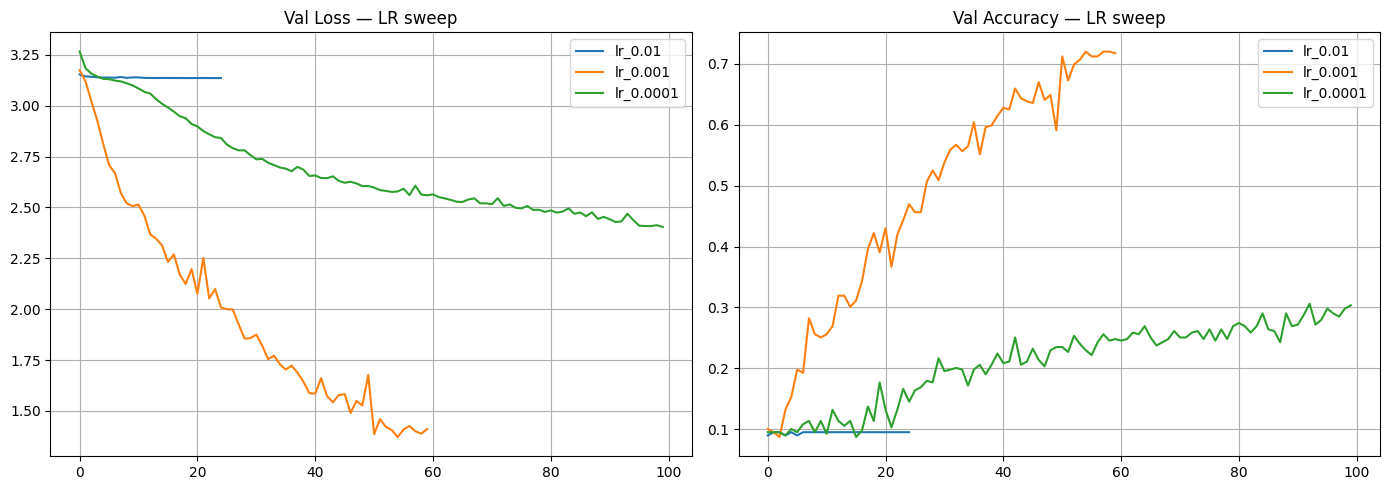

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100
48/48 [==============================] - 45s 920ms/step - loss: 3.2239 - accuracy: 0.0825 - val_loss: 3.1446 - val_accuracy: 0.0950 - lr: 0.0010
Epoch 2/100
48/48 [==============================] - 44s 913ms/step - loss: 3.1624 - accuracy: 0.0851 - val_loss: 3.1495 - val_accuracy: 0.0897 - lr: 0.0010
Epoch 3/100
48/48 [==============================] - 44s 920ms/step - loss: 3.1503 - accuracy: 0.0759 - val_loss: 3.1243 - val_accuracy: 0.0897 - lr: 0.0010
Epoch 4/100
48/48 [==============================] - 44s 913ms/step - loss: 3.1163 - accuracy: 0.0983 - val_loss: 3.0567 - val_accuracy: 0.1266 - lr: 0.0010
Epoch 5/100
48/48 [==============================] - 45s 931ms/step - loss: 2.9731 - accuracy: 0.1075 - val_loss: 3.1290 - val_accuracy: 0.0950 - lr: 0.0010
Epoch 6/100
48/48 [==============================] - 45s 932ms/step - loss: 2.8842 - accuracy: 0.1471 - val_loss: 2.7906 - val_accuracy: 0.1187 - lr: 0.0010
Epoch 7/100
48/48 [==============================] - 45s 9

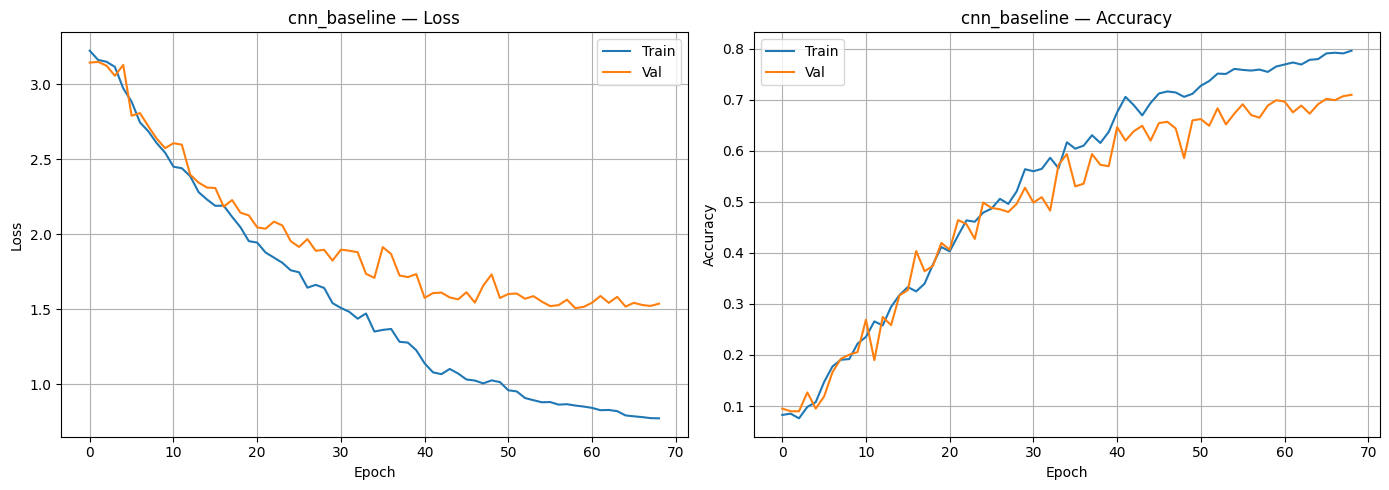

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

cnn_baseline (best LR=0.001):
  Train — Loss: 0.8208, Acc: 0.7817
  Val   — Loss: 1.5073, Acc: 0.6887


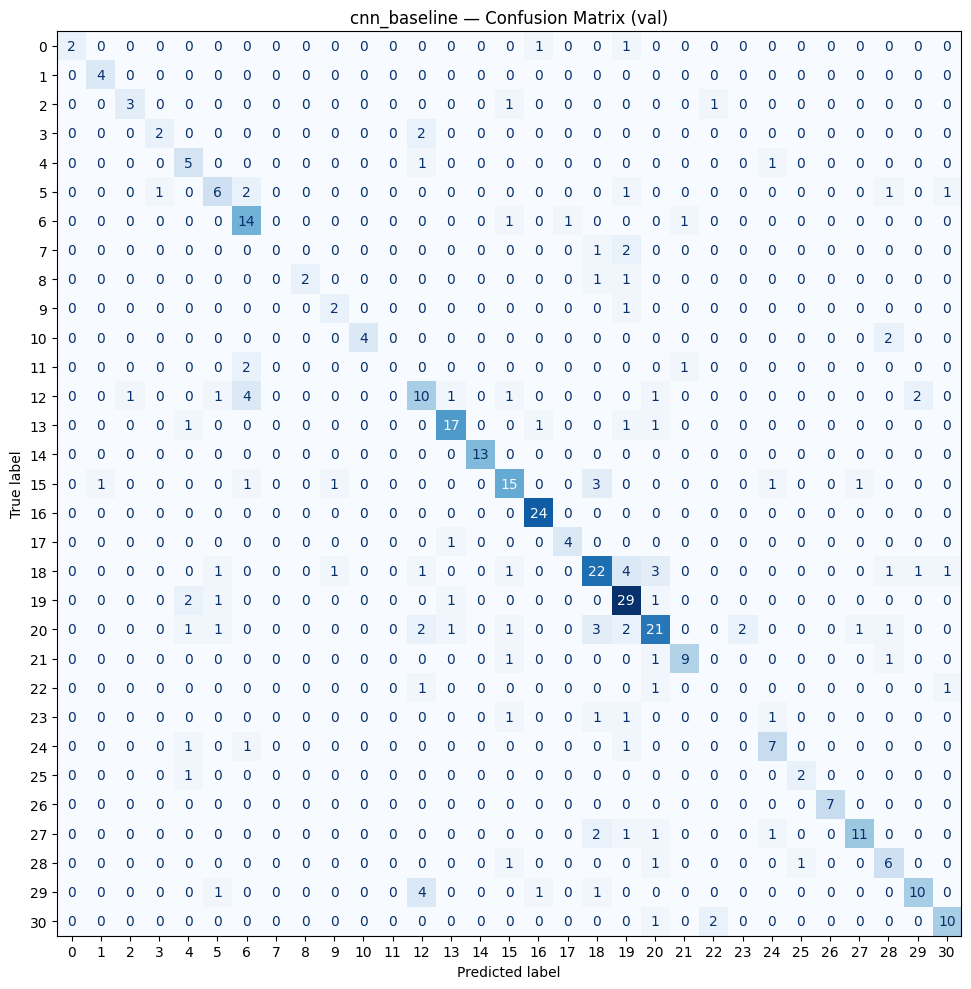

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 55 epochs
Epoch 1/55
60/60 [==============================] - 54s 898ms/step - loss: 3.1973 - accuracy: 0.0850
Epoch 2/55
60/60 [==============================] - 54s 899ms/step - loss: 3.1488 - accuracy: 0.0992
Epoch 3/55
60/60 [==============================] - 54s 903ms/step - loss: 3.1199 - accuracy: 0.1008
Epoch 4/55
60/60 [==============================] - 54s 898ms/step - loss: 3.0595 - accuracy: 0.1008
Epoch 5/55
60/60 [==============================] - 53s 883ms/step - loss: 2.9520 - accuracy: 0.1335
Epoch 6/55
60/60 [==============================] - 53s 886ms/step - loss: 2.8090 - accuracy: 0.1736
Epoch 7/55
60/60 [==============================] - 53s 887ms/step - loss: 2.6441 - accuracy: 0.2063
Epoch 8/55
60/60 [==============================] - 53s 890ms/step - loss: 2.5161 - accuracy: 0.2427
Epoch 9/55
60/60 [==============================] - 53s 889ms/step - loss: 2.4710 - accuracy: 0.2385
Epoch 10/55
60/60 [=================

In [14]:
X_test, test_filenames = load_data('test')

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

del X_test  # free memory

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 [==============================] - 2s 122ms/step
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_cnn_baseline.csv


,row_id,similarity
0,0,0.899982
1,1,0.398577
2,2,0.464700
3,3,0.465953
4,4,0.481260


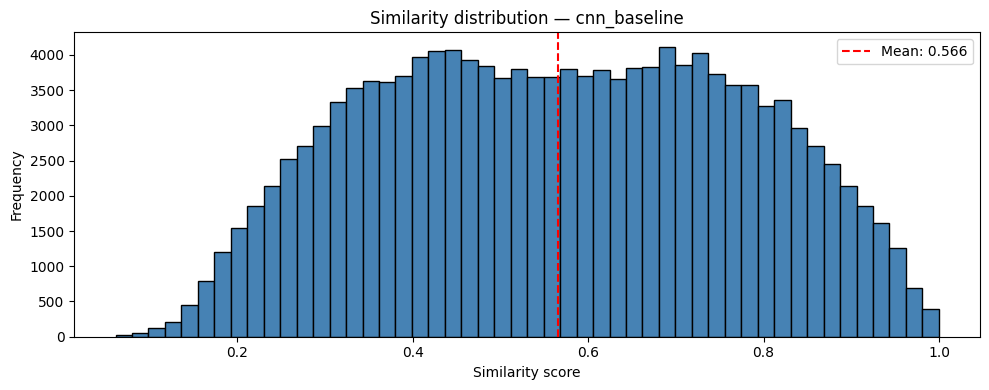

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

### Résultats

| Metrique | Train | Val |
|----------|-------|-----|
| Accuracy | 0.7817 | 0.6887 |
| Loss     | 0.8208 | 1.5073 |
| Overfitting ? | — | Modéré |
| Kaggle Score (public) | — | 0.267 |
| Kaggle Score (private) | — | 0.264 |

### Analyse des hyperparamètres

**Hyperparamètres du modèle :**

- **Structure (3 blocs Conv2D + MaxPool → GAP → Dense(128) → Dense(31))** : Premier modèle à préserver la structure spatiale 2D des images. Les 3 blocs convolutionnels réduisent progressivement la résolution (224→112→56→28) tout en augmentant le nombre de filtres (32→64→128). Chaque filtre apprend à détecter un pattern visuel spécifique (bord, texture, tache). Avec seulement 113k paramètres (vs 4.6M linéaire, 38.5M MLP), le CNN est ~40x plus efficient que le linéaire et ~340x plus efficient que le MLP, tout en obtenant un meilleur score Kaggle.

- **GlobalAveragePooling2D vs Flatten** : Le GAP compresse la carte de features 28×28×128 en un vecteur de 128 dims en moyennant chaque filtre sur toute la surface spatiale. Contrairement au Flatten (qui donnerait 28×28×128 = 100k dims), le GAP force le réseau à apprendre des features globales plutôt que positionnelles, et produit des embeddings compacts et transférables. C'est ce qui explique le bond en Kaggle : les embeddings 128-dims du CNN capturent des features sémantiques, pas des positions de pixels.

- **Fonctions d'activation (relu + softmax)** : ReLU dans les conv layers et la couche Dense(128). Choix standard pour les CNN — ReLU est computationnellement léger et évite le problème de vanishing gradient. Pour un CNN de 3 blocs, pas besoin d'alternatives plus sophistiquées (LeakyReLU, ELU).

- **Padding (same)** : Conserve les dimensions spatiales après chaque convolution (seul le MaxPool réduit). Cela évite de perdre des pixels en bordure d'image, important quand les taches du jaguar peuvent être proches des bords.

- **Data augmentation (none)** : Laissée à `none` pour cette baseline afin d'isoler l'impact de l'architecture seule. Contrairement au linéaire/MLP, l'augmentation a maintenant du sens avec un CNN : les convolutions sont translation-équivariantes, un flip horizontal préserve les patterns de taches. C'est une piste d'amélioration directe pour la version improved.

**Paramètres d'apprentissage :**

- **Learning rate (sweep : 0.01, 0.001, 0.0001)** : Le LR est très discriminant pour le CNN. lr=0.01 effondre le modèle à 9.5% (hasard) — les gradients sont trop grands pour les poids des convolutions, qui sont des petites matrices 3×3 très sensibles aux mises à jour brutales. lr=0.0001 est trop lent : seulement 30.3% après 100 epochs, le modèle n'a pas convergé (EarlyStopping n'a même pas déclenché). lr=0.001 est le sweet spot (72%), offrant un bon compromis convergence/stabilité. La sensibilité au LR est plus forte que pour le linéaire (où les 3 LR donnaient ~72%) mais comparable au MLP.

- **Optimizer (Adam)** : Adam avec ses moments adaptatifs est bien adapté aux CNN car les différentes couches (conv proches de l'entrée vs Dense proche de la sortie) ont des magnitudes de gradients très différentes. Adam ajuste le LR effectif par paramètre, ce qui aide à la convergence.

- **Batch size (32)** : Valeur par défaut. Pour un CNN de 113k params, le batch size a peu d'impact sur la qualité des gradients. Par contre, les convolutions sont plus lentes que les opérations Dense — chaque epoch prend ~53s (vs ~1s pour le linéaire) en raison des opérations de convolution sur CPU.

- **EarlyStopping (patience=5) et ReduceLROnPlateau (patience=3)** : Patience réduite par rapport au template (10/5) pour accélérer le sweep sur CPU. Le best_epoch=55 pour lr=0.001 montre que le CNN a besoin de beaucoup plus d'epochs que le linéaire (33) ou le MLP (33) pour converger, car les features spatiales s'apprennent progressivement couche par couche. La section 4 utilise patience=10/5 pour l'évaluation finale.

**Overfitting :**

Gap train/val de ~9 points (78.2% vs 68.9%), nettement mieux contenu que le linéaire (~27 pts) et le MLP (~33 pts). Le ratio paramètres/données (113k / 1516 ≈ 75 params/image) est beaucoup plus raisonnable que le linéaire (3000) et le MLP (25 000). La val_loss (1.51) reste raisonnable contrairement au linéaire (8.38). Le modèle n'a pas mémorisé le dataset — il a appris des features visuelles qui généralisent. Il y a de la marge pour pousser le modèle plus loin avec de la régularisation (Dropout, augmentation).

### Verdict

- [x] Improvable → Le CNN baseline montre un potentiel clair avec un Kaggle score en forte hausse (+62%) et un overfitting contenu. Pistes pour la version improved :
  1. **Data augmentation** (`moderate`) : flips, brightness, contrast — le CNN peut en bénéficier contrairement aux modèles précédents
  2. **BatchNormalization** après chaque Conv2D pour stabiliser les activations et accélérer la convergence
  3. **Dropout** (0.3) avant la Dense(128) pour régulariser les embeddings
  4. **4e bloc conv** (256 filtres) pour capturer des features plus abstraites (14×14 feature maps)

### Interprétation

Le CNN baseline marque un tournant dans la progression du projet. Malgré une accuracy de classification légèrement inférieure au linéaire (68.9% vs 73.1%), le score Kaggle bondit de 0.165 à 0.267 (+62%). Cette dissociation entre accuracy et score Kaggle est un enseignement fondamental : pour le re-ID, la qualité des embeddings compte plus que la précision de classification. Les convolutions apprennent des patterns visuels (taches, textures, contours) invariants à la pose et à l'angle, là où les pixels bruts échouent. Avec seulement 113k paramètres, c'est aussi le modèle le plus efficient. Le gap train/val modéré montre qu'il y a de la marge pour améliorer via augmentation, régularisation, et profondeur accrue.

## 6. Observations & Verdict